In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [55]:
def get_counts(df_input:pd.DataFrame, freq:str='M') ->pd.DataFrame:
    df = df_input.copy() # Evito modificar el df original por referencia
    df['epu_raw'] = df['matches'] / df['total']

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors="coerce")
    df['month'] = df.index.to_period(freq)

    monthly = df.groupby(['medio', 'month']).agg({'matches': 'sum', 'total': 'sum'}).reset_index()
    monthly['epu_raw'] = monthly['matches'] / monthly['total']
    monthly['epu_std'] = monthly.groupby('medio')['epu_raw'].transform(lambda x: x / x.std()) # Estandarizo los medios para evitar sesgos

    monthly_mean = monthly.groupby('month').agg({'epu_std': 'sum'}).reset_index() # Sumo los medios
    monthly_mean.set_index('month', inplace=True)
    return pd.DataFrame(monthly_mean['epu_std'])

In [56]:
BASE_DIR = 'D:/Leonardo/UDESA - CENTRO Cuantitativo/EPU ARG/src'
save__base_results_dir = Path(BASE_DIR).parent / "data"


In [57]:
#cargo EPU Udesa
results_udesa_file = save__base_results_dir / "results" / "epu_analysis_results_udesa_jp.xlsx"
udesa_epu = pd.read_excel(results_udesa_file)
udesa_epu.set_index('fecha', inplace=True)

In [ ]:
udesa_epu = pd.DataFrame(udesa_epu['Exclude none'].loc["2016-01-01":]) # Filtro desde 2006

In [59]:
#Cargo el EPU base sin procesar

results_base_file = save__base_results_dir / "epu_argentina_key_words_gdelt_maped_jp_all_media_with_sentiment.csv"
base_epu = pd.read_csv(results_base_file)
base_epu.set_index('fecha', inplace=True)

In [60]:
#Cargo subcategorias
results_currency_file = save__base_results_dir / "subcategories" / "epu_argentina_key_words_gdelt_maped_jp_currency_crisis_maped_all_media_with_sentiment.csv"
base_currency = pd.read_csv(results_currency_file)
base_currency.set_index('fecha', inplace=True)

results_fiscal_file = save__base_results_dir / "subcategories" / "epu_argentina_key_words_gdelt_maped_jp_fiscal_maped_all_media_with_sentiment.csv"
base_fiscal = pd.read_csv(results_fiscal_file)
base_fiscal.set_index('fecha', inplace=True)

results_monetary_policy_file = save__base_results_dir / "subcategories" / "epu_argentina_key_words_gdelt_maped_jp_monetary_policy_maped_all_media_with_sentiment.csv"
base_monetary_policy = pd.read_csv(results_monetary_policy_file)
base_monetary_policy.set_index('fecha', inplace=True)

results_trade_file = save__base_results_dir / "subcategories" / "epu_argentina_key_words_gdelt_maped_jp_trade_maped_all_media_with_sentiment.csv"
base_trade = pd.read_csv(results_trade_file)
base_trade.set_index('fecha', inplace=True)

In [61]:
freq = 'M'  # 'M' for monthly, 'W' for weekly

In [66]:
counts_base = get_counts(base_epu, freq=freq)
counts_currency = get_counts(base_currency, freq=freq)
counts_fiscal = get_counts(base_fiscal, freq=freq)
counts_monetary_policy = get_counts(base_monetary_policy, freq=freq)
counts_trade = get_counts(base_trade, freq=freq)

In [67]:
counts_base.rename(columns={'epu_std': 'EPU Base'}, inplace=True)
counts_currency.rename(columns={'epu_std': 'EPU Currency Crisis'}, inplace=True)
counts_fiscal.rename(columns={'epu_std': 'EPU Fiscal'}, inplace=True)
counts_monetary_policy.rename(columns={'epu_std': 'EPU Monetary Policy'}, inplace=True)
counts_trade.rename(columns={'epu_std': 'EPU Trade'}, inplace=True)

df_all = counts_base.join([counts_currency, counts_fiscal, counts_monetary_policy, counts_trade], how='outer')
df_all.index = df_all.index.to_timestamp()
df_all.index.name = 'Date'

<Axes: xlabel='Date'>

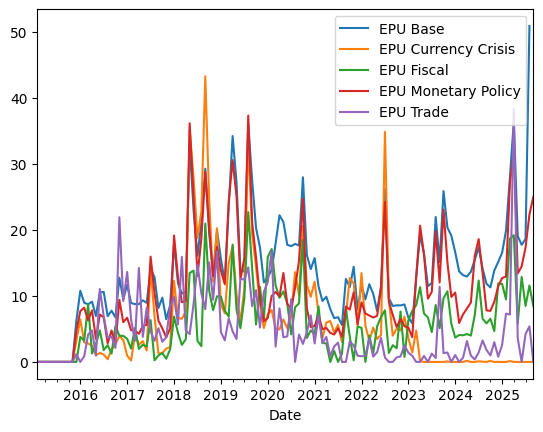

In [68]:
df_all.plot()

In [71]:
df_plot = pd.DataFrame()
df_plot['sum_sub'] = (df_all['EPU Currency Crisis'] + df_all['EPU Fiscal'] + df_all['EPU Monetary Policy'] + df_all['EPU Trade'])

df_plot['sum_sub'] = df_plot['sum_sub'].replace(0, 0.0001) # Evitar división por cero
df_plot = df_plot.dropna(axis = 0, how = "any")  
df_plot['prop_currency'] = df_all['EPU Currency Crisis'] / df_plot['sum_sub']
df_plot['prop_fiscal'] = df_all['EPU Fiscal'] / df_plot['sum_sub']
df_plot['prop_monetary'] = df_all['EPU Monetary Policy'] / df_plot['sum_sub']
df_plot['prop_trade'] = df_all['EPU Trade'] / df_plot['sum_sub']

df_plot[['prop_currency', 'prop_fiscal', 'prop_monetary', 'prop_trade']] = df_plot[['prop_currency', 'prop_fiscal', 'prop_monetary', 'prop_trade']].fillna(0)

df_plot['EPU_Base_norm'] = df_all['EPU Base'] / df_all['EPU Base'].max()

In [74]:
df_plot = df_plot.loc[udesa_epu.index[0]:]
df_plot.head()


,sum_sub,prop_currency,prop_fiscal,prop_monetary,prop_trade,EPU_Base_norm
Date,,,,,,
2016-01-01,17.917807,0.359728,0.211114,0.429158,0.000000,0.211755
2016-02-01,15.231925,0.194449,0.210790,0.539219,0.055542,0.175970
2016-03-01,21.989981,0.127104,0.397824,0.286089,0.188983,0.171737
2016-04-01,16.282455,0.150433,0.078277,0.478879,0.292411,0.179262
2016-05-01,8.152673,0.120008,0.329088,0.427918,0.122986,0.136556


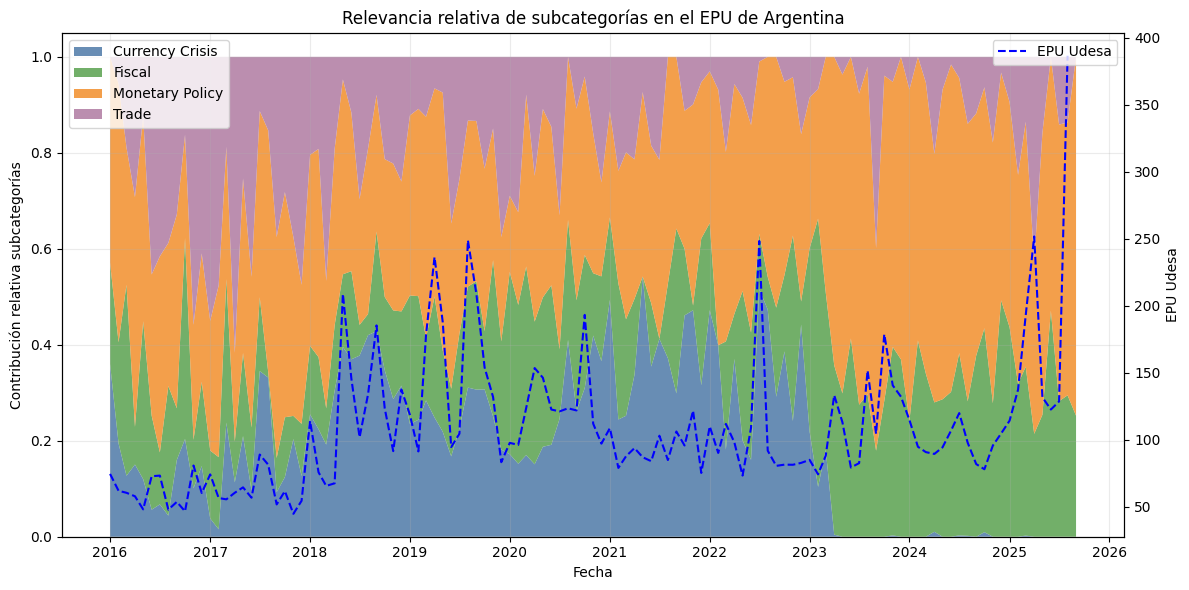

In [87]:
palette = ["#4E79A7", "#59A14F", "#F28E2B", "#B07AA1"]

fig, ax1 = plt.subplots(figsize=(12, 6))

cols = ['prop_currency','prop_fiscal','prop_monetary','prop_trade']
labels = ['Currency Crisis', 'Fiscal', 'Monetary Policy', 'Trade']
stack = ax1.stackplot(
    df_plot.index,
    *[df_plot[c].values for c in cols],
    labels=labels,
    colors=palette,
    alpha=0.85
)

ax1.set_xlabel('Fecha')
ax1.set_ylabel('Contribución relativa subcategorías')
ax1.set_title('Relevancia relativa de subcategorías en el EPU de Argentina')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(udesa_epu, color='blue', linestyle='--', label='EPU Udesa')
ax2.set_ylabel('EPU Udesa')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.0)

plt.tight_layout()
plt.show()